# Blood Cell AI - 最終評価

ResNet18とViT-B/16の学習結果を比較します（TF版 / PyTorch版 別々に表示）

## 1. インポートと設定

In [1]:
import os
import sys
import matplotlib.pyplot as plt
import japanize_matplotlib
import numpy as np
import seaborn as sns

sys.path.append(os.path.abspath('..'))
from utils.results import load_results

RESULTS_DIR = '../models'
PT_RESULTS_DIR = '../pytorch_results'
IMAGES_DIR = '../images'
os.makedirs(IMAGES_DIR, exist_ok=True)


## 2. 結果読み込み

In [2]:
def load_r(filepath):
    try:
        r = load_results(filepath)
        print(f'OK: {os.path.basename(filepath)}')
        return r
    except FileNotFoundError:
        print(f'Skip: {os.path.basename(filepath)}')
        return None

# TF版（finetuning + feature_extraction）
tf_results = []
for name in ['resnet18_finetuning', 'resnet18_feature_extraction',
             'vit_b16_finetuning', 'vit_b16_feature_extraction']:
    r = load_r(f'{RESULTS_DIR}/{name}_results.yaml')
    if r: tf_results.append(r)

# PyTorch版
pt_results = []
for name in ['resnet18_finetuning', 'resnet18_feature_extraction',
             'vit_b16_finetuning', 'vit_b16_feature_extraction']:
    r = load_r(f'{PT_RESULTS_DIR}/{name}_results.yaml')
    if r: pt_results.append(r)

print(f'\nTF: {len(tf_results)}件, PyTorch: {len(pt_results)}件')


OK: resnet18_finetuning_results.yaml
OK: resnet18_feature_extraction_results.yaml
OK: vit_b16_finetuning_results.yaml
OK: vit_b16_feature_extraction_results.yaml
OK: resnet18_finetuning_results.yaml
OK: resnet18_feature_extraction_results.yaml
OK: vit_b16_finetuning_results.yaml
OK: vit_b16_feature_extraction_results.yaml

TF: 4件, PyTorch: 4件


## 3. 結果サマリー

In [3]:
def show_results(results, title):
    print(f'\n===== {title} =====')
    for r in results:
        cm = np.array(r['confusion_matrix'])
        print(f"  {r['model']} ({r.get('approach','?')})")
        print(f"    Accuracy: {r['test_accuracy']:.4f}")
        print(f"    F1:       {r['test_f1']:.4f}")
        print(f"    Time:     {r['training_time_minutes']:.1f}分")
        print(f"    CM:\n{cm}")

if tf_results:
    show_results(tf_results, 'TensorFlow (ROCm / RX 7900 XT)')
if pt_results:
    show_results(pt_results, 'PyTorch (CUDA / RTX 3060)')


===== TensorFlow (ROCm / RX 7900 XT) =====
  ResNet18 (finetuning)
    Accuracy: 0.9348
    F1:       0.8814
    Time:     2.3分
    CM:
[[2369  162]
 [  61  829]]
  ResNet18 (feature_extraction)
    Accuracy: 0.8384
    F1:       0.6520
    Time:     0.8分
    CM:
[[2350  181]
 [ 372  518]]
  ViT-B16 (finetuning)
    Accuracy: 0.9062
    F1:       0.8304
    Time:     20.0分
    CM:
[[2314  217]
 [ 104  786]]
  ViT-B16 (feature_extraction)
    Accuracy: 0.7615
    F1:       0.2093
    Time:     6.4分
    CM:
[[2497   34]
 [ 782  108]]

===== PyTorch (CUDA / RTX 3060) =====
  ResNet18 (finetuning)
    Accuracy: 0.9556
    F1:       0.9139
    Time:     0.8分
    CM:
[[2462   69]
 [  83  807]]
  ResNet18 (feature_extraction)
    Accuracy: 0.7895
    F1:       0.5750
    Time:     0.7分
    CM:
[[2214  317]
 [ 403  487]]
  ViT-B/16 (finetuning)
    Accuracy: 0.8878
    F1:       0.8027
    Time:     16.6分
    CM:
[[2256  275]
 [ 109  781]]
  ViT-B/16 (feature_extraction)
    Accuracy: 0.8886


## 4. フレームワーク別 比較グラフ

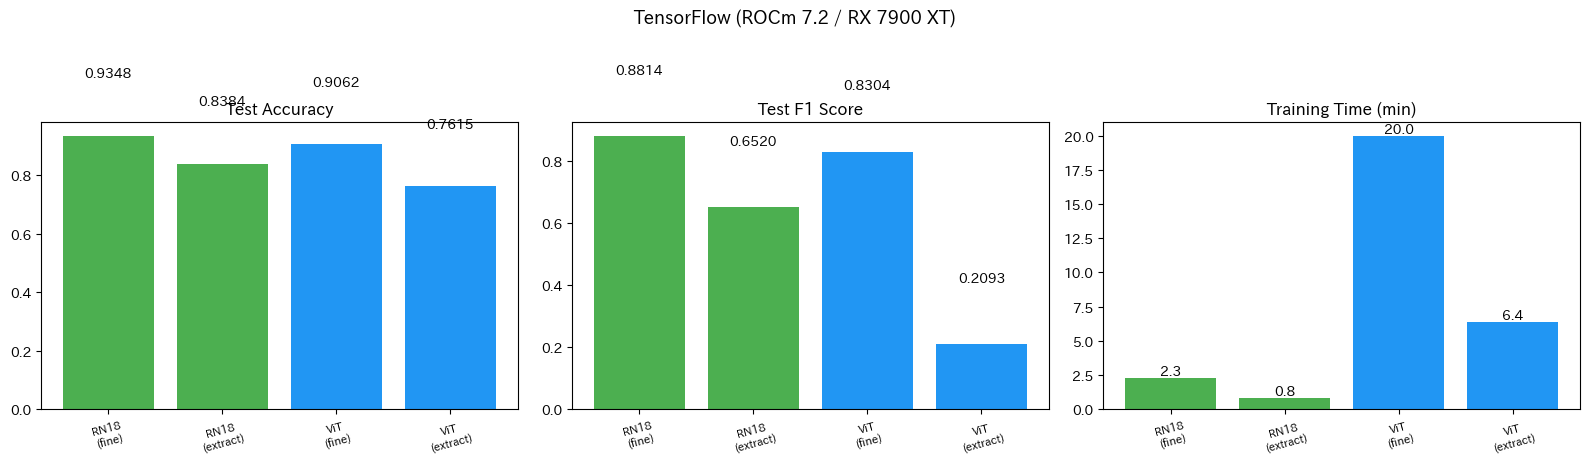

保存: ../images/tf_comparison.png


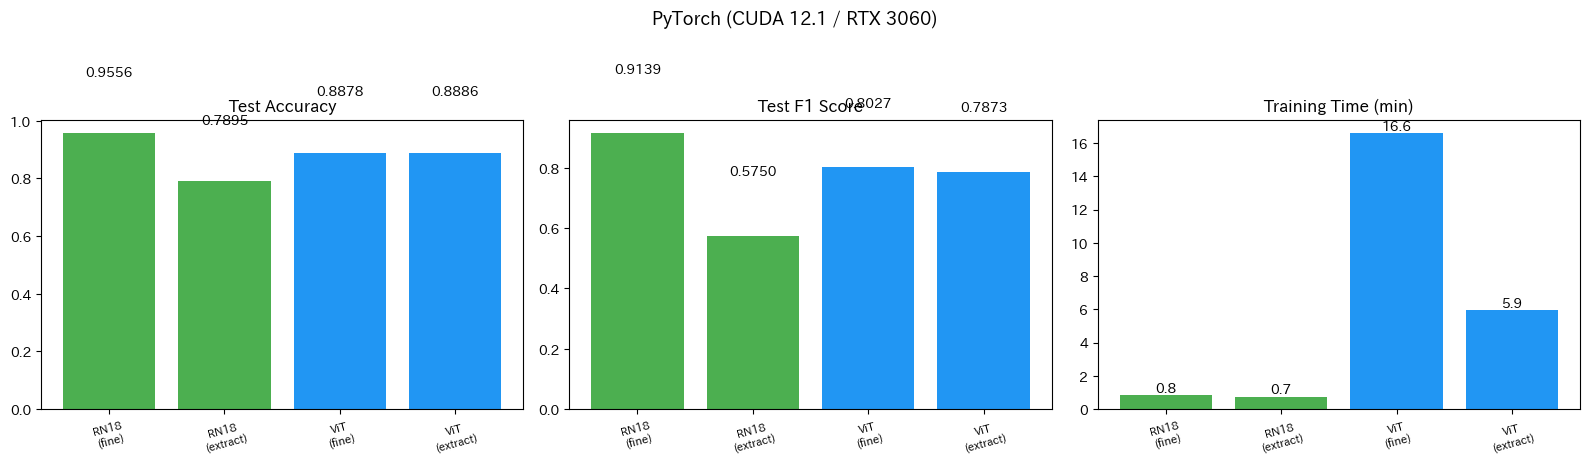

保存: ../images/pt_comparison.png


In [4]:
def plot_comparison(results, title, color_map, save_name):
    if len(results) < 2:
        print(f'{title}: 比較対象が不足')
        return
    labels = []
    for r in results:
        m = r['model'].replace('ResNet18', 'RN18').replace('ViT-B16', 'ViT').replace('ViT-B/16', 'ViT')
        a = 'fine' if r.get('approach') == 'finetuning' else 'extract'
        labels.append(f'{m}\n({a})')
    acc = [r['test_accuracy'] for r in results]
    f1 = [r['test_f1'] for r in results]
    times = [r['training_time_minutes'] for r in results]
    colors = [color_map.get(r['model'], '#999') for r in results]

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    fig.suptitle(title, fontsize=13)

    for ax, vals, title_ax, ylim, fmt in [
        (axes[0], acc, 'Test Accuracy', None, '.4f'),
        (axes[1], f1, 'Test F1 Score', None, '.4f'),
        (axes[2], times, 'Training Time (min)', None, '.1f'),
    ]:
        bars = ax.bar(labels, vals, color=colors)
        ax.set_title(title_ax)
        if ylim: ax.set_ylim(ylim)
        ax.tick_params(axis='x', labelsize=8, rotation=15)
        for bar, val in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() + (0.005 if ylim else 0.2),
                    f'{val:{fmt}}', ha='center', fontsize=10)

    plt.tight_layout()
    plt.subplots_adjust(bottom=0.18)
    plt.savefig(f'{IMAGES_DIR}/{save_name}.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'保存: {IMAGES_DIR}/{save_name}.png')

cmap = {'ResNet18': '#4CAF50', 'ViT-B16': '#2196F3', 'ViT-B/16': '#2196F3'}
if tf_results:
    plot_comparison(tf_results, 'TensorFlow (ROCm 7.2 / RX 7900 XT)', cmap, 'tf_comparison')
if pt_results:
    plot_comparison(pt_results, 'PyTorch (CUDA 12.1 / RTX 3060)', cmap, 'pt_comparison')


## 6. 各フレームワークの詳細

### TensorFlow (ROCm 7.2 / RX 7900 XT)

| モデル | アプローチ | Accuracy | F1 | 学習時間 | VRAM使用量 |
|-------|-----------|:--------:|:--:|:--------:|:----------:|
| ResNet18 | finetuning | 93.5% | 88.1% | 2.3分 | 未計測 |
| ResNet18 | feature_extraction | 83.8% | 65.2% | 0.8分 | 未計測 |
| ViT-B/16 | finetuning | 90.6% | 83.0% | 20.0分 | 17GB |
| ViT-B/16 | feature_extraction | 76.1% | 20.9% | 6.4分 | 3GB |

### PyTorch (CUDA 12.1 / RTX 3060)

| モデル | アプローチ | Accuracy | F1 | 学習時間 | VRAM使用量 |
|-------|-----------|:--------:|:--:|:--------:|:----------:|
| ResNet18 | finetuning | 95.6% | 91.4% | 0.8分 | 未計測 |
| ResNet18 | feature_extraction | 79.0% | 57.5% | 0.7分 | 未計測 |
| ViT-B/16 | finetuning | 88.8% | 80.3% | 16.6分 | 5.74GB |
| ViT-B/16 | feature_extraction | 88.9% | 78.7% | 5.9分 | 未計測 |

> ⚠️ TF版ViT finetuningはNaN回避のためLR=0.0005（PyTorchは0.001）。PyTorch版ViT finetuningは事前学習重みが未適用の可能性あり。


## 5. 混同行列

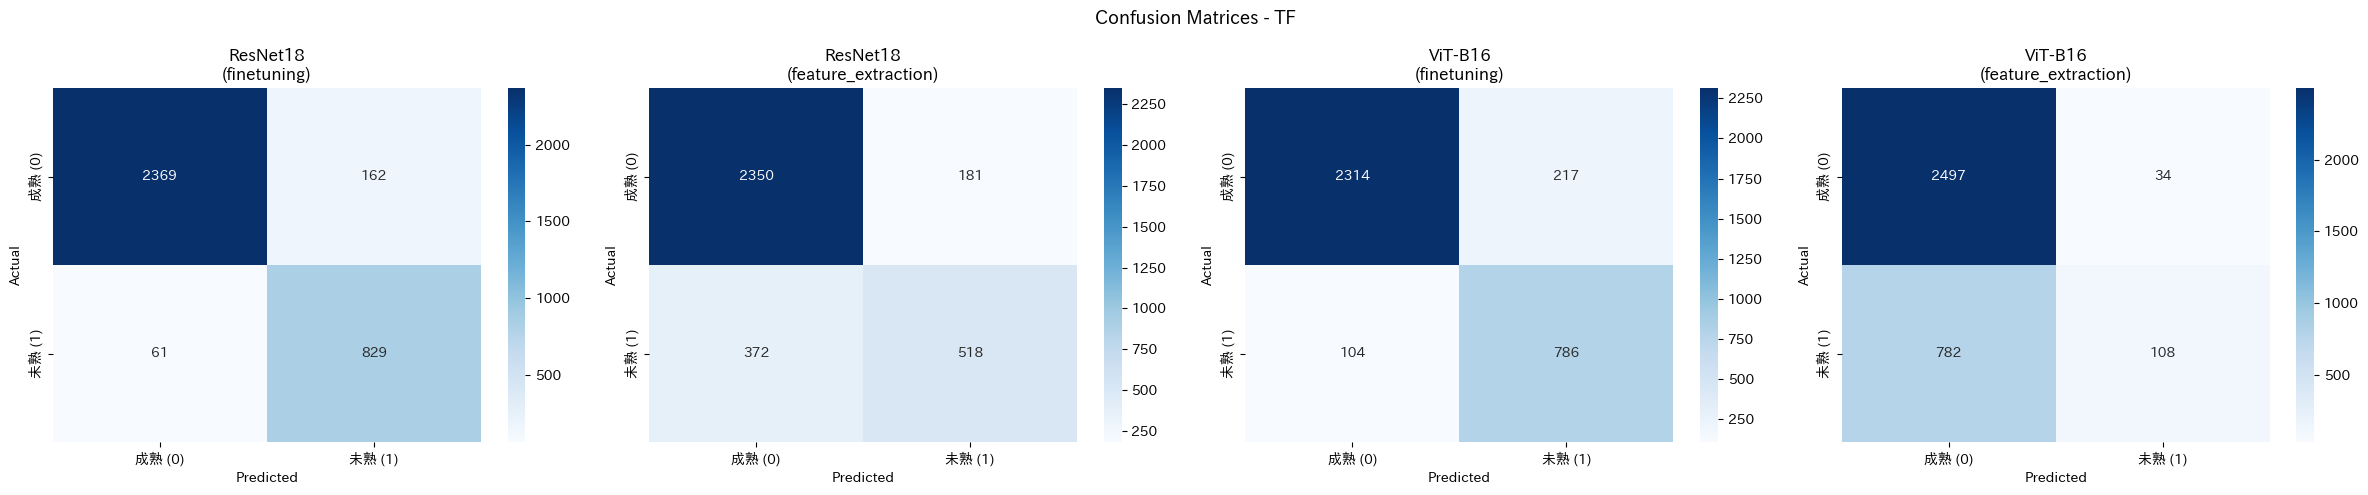

保存: ../images/tf_cm.png


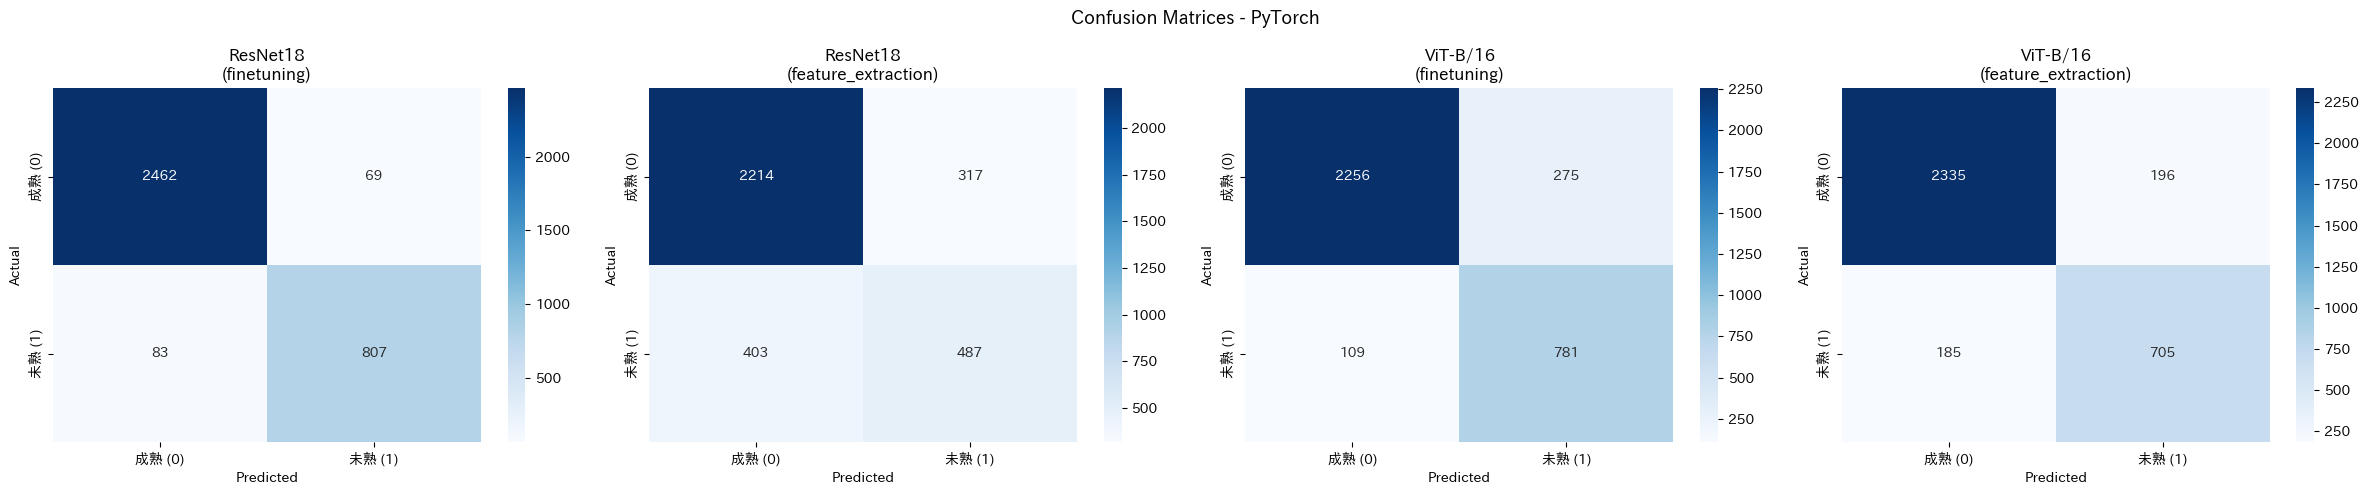

保存: ../images/pt_cm.png


In [5]:
def plot_cms(results, title, save_name):
    if not results:
        return
    n = len(results)
    fig, axes = plt.subplots(1, n, figsize=(6 * n, 5))
    if n == 1: axes = [axes]
    fig.suptitle(title, fontsize=13)
    cls = ['成熟 (0)', '未熟 (1)']
    for i, r in enumerate(results):
        cm = np.array(r['confusion_matrix'])
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                    xticklabels=cls, yticklabels=cls, ax=axes[i])
        axes[i].set_title(f"{r['model']}\n({r.get('approach','?')})")
        axes[i].set_ylabel('Actual')
        axes[i].set_xlabel('Predicted')
    plt.tight_layout()
    plt.savefig(f'{IMAGES_DIR}/{save_name}.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'保存: {IMAGES_DIR}/{save_name}.png')

if tf_results:
    plot_cms(tf_results, 'Confusion Matrices - TF', 'tf_cm')
if pt_results:
    plot_cms(pt_results, 'Confusion Matrices - PyTorch', 'pt_cm')